# Ejemplo 1 — ABC para Feature Selection

**Actividad 03 — Algoritmos de Enjambre aplicados al Aprendizaje Automático**

## Objetivo

Aplicar una **adaptación binaria del algoritmo Artificial Bee Colony (ABC)** para seleccionar las mejores características (*feature selection*) del dataset Wine.

### Correspondencia con el ciclo solicitado

- **Representación:** una fuente de alimento es un cromosoma binario de 13 posiciones.
- **Inicialización:** se crean fuentes de alimento aleatorias.
- **Aptitud:** accuracy de Regresión Logística con validación cruzada, menos una pequeña penalización por usar muchas características.
- **Comportamiento:** abejas empleadas exploran su fuente; observadoras eligen fuentes prometedoras; exploradoras reemplazan fuentes estancadas.
- **Evolución:** las mejores fuentes sustituyen a las peores soluciones locales.
- **Finalización:** termina después de un número fijo de ciclos.

In [1]:
import random
from functools import lru_cache
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)

datos = load_wine()
X = datos.data
y = datos.target
nombres = list(datos.feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=SEMILLA
)

print("Dataset Wine")
print("Registros:", X.shape[0])
print("Características:", X.shape[1])
print("Clases:", len(np.unique(y)))
print("Train:", X_train.shape, "| Test:", X_test.shape)

Dataset Wine
Registros: 178
Características: 13
Clases: 3
Train: (133, 13) | Test: (45, 13)


## 1. Representación de la fuente de alimento

En esta adaptación binaria de ABC, cada fuente representa una posible selección de características:

`1 = usar la característica`  
`0 = descartar la característica`

Ejemplo: `[1,0,1,0,...]`

In [2]:
def crear_fuente(numero_caracteristicas):
    fuente = [random.randint(0, 1) for _ in range(numero_caracteristicas)]
    if sum(fuente) == 0:
        fuente[random.randrange(numero_caracteristicas)] = 1
    return fuente

def vecina_binaria(fuente):
    """Genera una solución vecina cambiando un bit."""
    vecina = fuente.copy()
    posicion = random.randrange(len(vecina))
    vecina[posicion] = 1 - vecina[posicion]

    if sum(vecina) == 0:
        vecina[random.randrange(len(vecina))] = 1

    return vecina

ejemplo = crear_fuente(X_train.shape[1])
print("Fuente ejemplo:", ejemplo)
print("Número de características seleccionadas:", sum(ejemplo))

Fuente ejemplo: [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
Número de características seleccionadas: 2


## 2. Función de aptitud

Cada fuente selecciona un subconjunto de columnas. Ese subconjunto se evalúa con una Regresión Logística mediante validación cruzada estratificada de 3 particiones.

Se usa:

`fitness = accuracy_cv - 0.01 × proporción_de_características_seleccionadas`

La penalización es pequeña y solo favorece soluciones compactas cuando el rendimiento es parecido.

In [3]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEMILLA)

@lru_cache(maxsize=None)
def fitness_abc(fuente_tupla):
    fuente = list(fuente_tupla)
    mascara = np.array(fuente, dtype=bool)

    if mascara.sum() == 0:
        return -1.0

    modelo = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1500, random_state=SEMILLA)
    )

    accuracy_cv = cross_val_score(
        modelo,
        X_train[:, mascara],
        y_train,
        cv=cv,
        scoring="accuracy"
    ).mean()

    penalizacion = 0.01 * (mascara.sum() / len(mascara))
    return accuracy_cv - penalizacion

## 3. ABC completo

Fases implementadas:

1. **Abejas empleadas:** cada fuente genera una vecina y conserva la mejor.
2. **Abejas observadoras:** eligen fuentes con probabilidad proporcional a su calidad y vuelven a buscar vecinas.
3. **Abejas exploradoras:** si una fuente no mejora durante varios intentos, se abandona y se genera una nueva fuente aleatoria.
4. Se conserva la mejor solución global.

In [4]:
def algoritmo_abc_feature_selection(
    numero_fuentes=8,
    ciclos=8,
    limite=4
):
    random.seed(SEMILLA)
    np.random.seed(SEMILLA)
    fitness_abc.cache_clear()

    # Inicialización del enjambre / fuentes de alimento
    fuentes = [
        crear_fuente(X_train.shape[1])
        for _ in range(numero_fuentes)
    ]
    aptitudes = [fitness_abc(tuple(f)) for f in fuentes]
    intentos_sin_mejora = [0] * numero_fuentes

    mejor_idx = int(np.argmax(aptitudes))
    mejor_fuente = fuentes[mejor_idx].copy()
    mejor_aptitud = aptitudes[mejor_idx]

    historial = []

    print("INICIO ABC - FEATURE SELECTION")
    print("=" * 80)

    for ciclo in range(1, ciclos + 1):

        # ----------------------------------------------------
        # FASE 1: ABEJAS EMPLEADAS
        # ----------------------------------------------------
        for i in range(numero_fuentes):
            candidata = vecina_binaria(fuentes[i])
            aptitud_candidata = fitness_abc(tuple(candidata))

            if aptitud_candidata > aptitudes[i]:
                fuentes[i] = candidata
                aptitudes[i] = aptitud_candidata
                intentos_sin_mejora[i] = 0
            else:
                intentos_sin_mejora[i] += 1

        # ----------------------------------------------------
        # FASE 2: ABEJAS OBSERVADORAS
        # ----------------------------------------------------
        valores = np.array(aptitudes)
        probabilidades = valores - valores.min() + 1e-6
        probabilidades = probabilidades / probabilidades.sum()

        for _ in range(numero_fuentes):
            i = np.random.choice(numero_fuentes, p=probabilidades)
            candidata = vecina_binaria(fuentes[i])
            aptitud_candidata = fitness_abc(tuple(candidata))

            if aptitud_candidata > aptitudes[i]:
                fuentes[i] = candidata
                aptitudes[i] = aptitud_candidata
                intentos_sin_mejora[i] = 0
            else:
                intentos_sin_mejora[i] += 1

        # ----------------------------------------------------
        # FASE 3: ABEJAS EXPLORADORAS
        # ----------------------------------------------------
        for i in range(numero_fuentes):
            if intentos_sin_mejora[i] >= limite:
                fuentes[i] = crear_fuente(X_train.shape[1])
                aptitudes[i] = fitness_abc(tuple(fuentes[i]))
                intentos_sin_mejora[i] = 0

        # Mejor solución global
        idx = int(np.argmax(aptitudes))
        if aptitudes[idx] > mejor_aptitud:
            mejor_fuente = fuentes[idx].copy()
            mejor_aptitud = aptitudes[idx]

        historial.append({
            "ciclo": ciclo,
            "mejor_fitness": mejor_aptitud,
            "fitness_promedio": float(np.mean(aptitudes)),
            "numero_caracteristicas": sum(mejor_fuente)
        })

        print(
            f"Ciclo {ciclo:02d} | "
            f"Mejor fitness: {mejor_aptitud:.4f} | "
            f"Promedio: {np.mean(aptitudes):.4f} | "
            f"Características: {sum(mejor_fuente)}"
        )

    return mejor_fuente, mejor_aptitud, pd.DataFrame(historial)

mejor_fuente, mejor_fitness, historial_abc = algoritmo_abc_feature_selection()

INICIO ABC - FEATURE SELECTION


Ciclo 01 | Mejor fitness: 0.9721 | Promedio: 0.9119 | Características: 7


Ciclo 02 | Mejor fitness: 0.9730 | Promedio: 0.9280 | Características: 6


Ciclo 03 | Mejor fitness: 0.9730 | Promedio: 0.9536 | Características: 6


Ciclo 04 | Mejor fitness: 0.9796 | Promedio: 0.9339 | Características: 7


Ciclo 05 | Mejor fitness: 0.9863 | Promedio: 0.9285 | Características: 8


Ciclo 06 | Mejor fitness: 0.9863 | Promedio: 0.9283 | Características: 8


Ciclo 07 | Mejor fitness: 0.9872 | Promedio: 0.9489 | Características: 7


Ciclo 08 | Mejor fitness: 0.9872 | Promedio: 0.9619 | Características: 7


In [5]:
# Decodificación y evaluación final en TEST
mascara_final = np.array(mejor_fuente, dtype=bool)
caracteristicas_seleccionadas = [
    nombre for nombre, usar in zip(nombres, mejor_fuente) if usar
]

modelo_final = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1500, random_state=SEMILLA)
)
modelo_final.fit(X_train[:, mascara_final], y_train)
predicciones = modelo_final.predict(X_test[:, mascara_final])
accuracy_test = accuracy_score(y_test, predicciones)

print("\nRESULTADO FINAL ABC")
print("=" * 60)
print("Mejor fuente:", mejor_fuente)
print("Características seleccionadas:", len(caracteristicas_seleccionadas), "de", len(nombres))
for c in caracteristicas_seleccionadas:
    print(" -", c)
print(f"Fitness: {mejor_fitness:.4f}")
print(f"Accuracy en test: {accuracy_test:.4f}")


RESULTADO FINAL ABC
Mejor fuente: [1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1]
Características seleccionadas: 7 de 13
 - alcohol
 - ash
 - alcalinity_of_ash
 - color_intensity
 - hue
 - od280/od315_of_diluted_wines
 - proline
Fitness: 0.9872
Accuracy en test: 1.0000


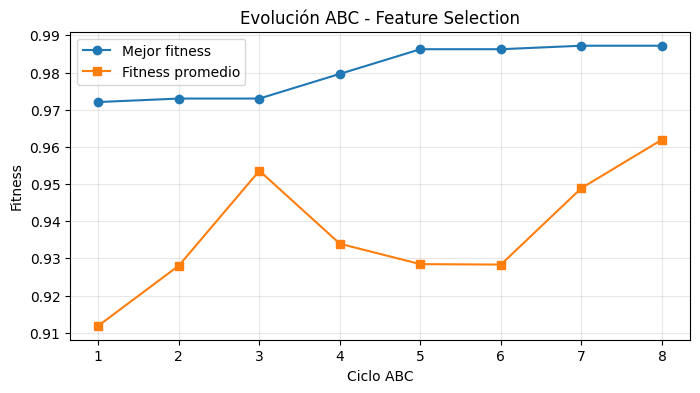

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(historial_abc["ciclo"], historial_abc["mejor_fitness"], marker="o", label="Mejor fitness")
plt.plot(historial_abc["ciclo"], historial_abc["fitness_promedio"], marker="s", label="Fitness promedio")
plt.xlabel("Ciclo ABC")
plt.ylabel("Fitness")
plt.title("Evolución ABC - Feature Selection")
plt.legend()
plt.grid(alpha=0.3)
plt.show()